# Churn Prediction — A Proper scikit-learn Pipeline

**Week 4 · Machine Learning Fundamentals — Build a Proper ML Pipeline with Feature Engineering**

Dataset: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Goals for this notebook:
1. Build a single `Pipeline` using `ColumnTransformer` (`StandardScaler` for numeric columns, `OneHotEncoder` for categorical columns).
2. Chain preprocessing and the model into one pipeline object — no manual, error-prone preprocessing.
3. Confirm the pipeline gives the same or better results than a manual preprocessing approach.
4. Engineer at least two new features and test whether they improve performance.
5. Save the final trained pipeline with `joblib`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

## 1. Load the data

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Clean the data

`TotalCharges` is stored as text and hides 11 blank values — all belonging to brand-new
customers with `tenure == 0`. We convert it to numeric and fill those with `0`, since a
customer with zero tenure genuinely has zero total charges billed so far.


In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"Missing TotalCharges before fix: {df['TotalCharges'].isna().sum()}")

df["TotalCharges"] = df["TotalCharges"].fillna(0)
print(f"Missing TotalCharges after fix:  {df['TotalCharges'].isna().sum()}")

# customerID is a unique identifier with no predictive signal
df = df.drop(columns=["customerID"])

# Encode the target as 0/1
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(f"\nRemaining nulls in dataset: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

Missing TotalCharges before fix: 11
Missing TotalCharges after fix:  0

Remaining nulls in dataset: 0
Final shape: (7043, 20)


## 3. Quick EDA

Overall churn rate: 26.5%


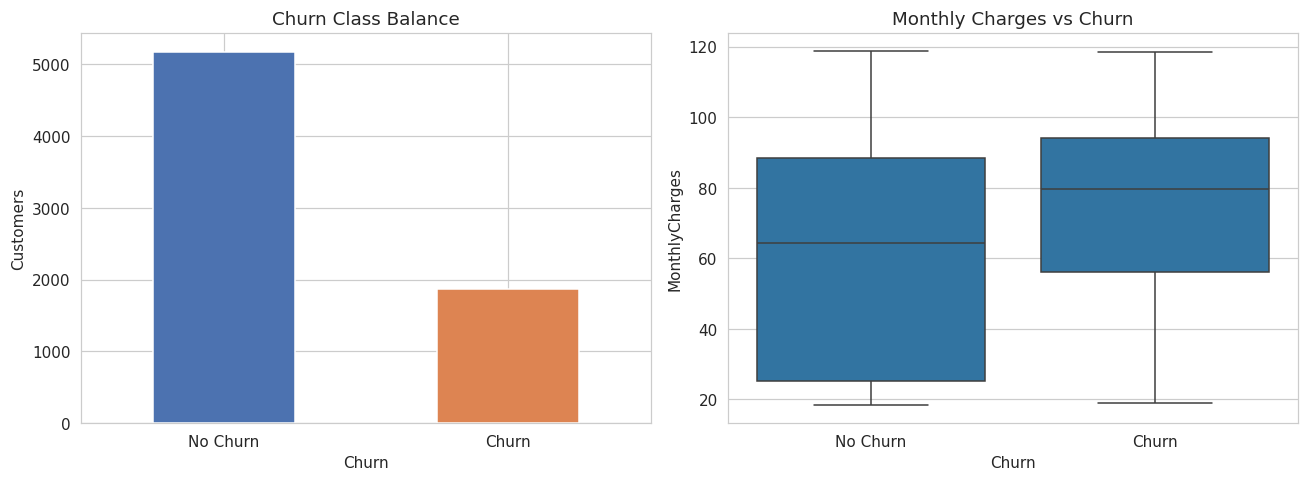

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df["Churn"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_xticklabels(["No Churn", "Churn"], rotation=0)
axes[0].set_title("Churn Class Balance")
axes[0].set_ylabel("Customers")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_xticklabels(["No Churn", "Churn"])
axes[1].set_title("Monthly Charges vs Churn")

plt.tight_layout()
plt.show()

print(f"Overall churn rate: {df['Churn'].mean():.1%}")

## 4. Feature engineering

Two new features (plus a bonus third), built purely from columns already in the raw data —
no leakage from the target:

- **`NumServices`** — how many of the 6 optional add-on services (online security, backup,
  device protection, tech support, streaming TV, streaming movies) the customer has. A
  customer with more add-ons is typically more "locked in" to the provider.
- **`AvgMonthlyCharge`** — `TotalCharges / tenure`. This is the customer's *true* historical
  average spend, which can differ from their *current* `MonthlyCharges` if their plan has
  changed over time (e.g. someone who recently upgraded will have a `MonthlyCharges` much
  higher than their long-run average).
- **`IsNewCustomer`** *(bonus)* — a flag for customers in their first 6 months, since churn
  is known to be heavily concentrated early in the customer lifecycle.


In [5]:
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
df["NumServices"] = (df[service_cols] == "Yes").sum(axis=1)

df["AvgMonthlyCharge"] = np.where(
    df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"]
)

df["IsNewCustomer"] = (df["tenure"] <= 6).astype(int)

df[["tenure", "NumServices", "AvgMonthlyCharge", "IsNewCustomer"]].head()

,tenure,NumServices,AvgMonthlyCharge,IsNewCustomer
0,1,1,29.850000,1
1,34,2,55.573529,0
2,2,2,54.075000,1
3,45,3,40.905556,0
4,2,0,75.825000,1


In [6]:
# Sanity check: do the engineered features actually separate churners from non-churners?
df.groupby("Churn")[["NumServices", "AvgMonthlyCharge", "IsNewCustomer"]].mean().round(2)

,NumServices,AvgMonthlyCharge,IsNewCustomer
Churn,,,
0,2.14,61.27,0.13
1,1.77,74.43,0.42


## 5. Train / test split

We define two feature sets:
- **`base_*`** — the original raw columns only (used for the "before" comparison).
- **`eng_*`** — the same columns *plus* our three engineered features (used for the "after"
  comparison).

The split is stratified on `Churn` since classes are imbalanced (~27% churn rate).


In [7]:
TARGET = "Churn"

base_numeric = ["tenure", "MonthlyCharges", "TotalCharges"]
# pandas 3.x reads text columns in as a native StringDtype rather than "object",
# so we detect categoricals with is_string_dtype (version-robust) instead of
# comparing dtype == "object" directly.
base_categorical = [
    c for c in df.columns
    if c != TARGET and pd.api.types.is_string_dtype(df[c])
]

eng_numeric = base_numeric + ["NumServices", "AvgMonthlyCharge", "IsNewCustomer"]
eng_categorical = base_categorical  # no new categorical columns were engineered

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Categorical columns ({len(base_categorical)}): {base_categorical}")

Train: (5634, 22) | Test: (1409, 22)
Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6. Baseline: manual preprocessing (the "old" way)

Before building the pipeline, we reproduce the manual approach most people start with:
`pd.get_dummies` for categoricals and a hand-fitted `StandardScaler` for numerics. This is
exactly the kind of code a `Pipeline` is meant to replace — it's verbose, and it's easy to
accidentally fit the scaler on the wrong data (leaking test information into training).


In [8]:
X_train_manual = X_train[base_numeric + base_categorical].copy()
X_test_manual = X_test[base_numeric + base_categorical].copy()

X_train_enc = pd.get_dummies(X_train_manual, columns=base_categorical, drop_first=True)
X_test_enc = pd.get_dummies(X_test_manual, columns=base_categorical, drop_first=True)

# Test set can be missing dummy columns for categories not seen there -- align manually
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

scaler = StandardScaler()
X_train_enc[base_numeric] = scaler.fit_transform(X_train_enc[base_numeric])
X_test_enc[base_numeric] = scaler.transform(X_test_enc[base_numeric])

manual_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
manual_model.fit(X_train_enc, y_train)

manual_pred = manual_model.predict(X_test_enc)
manual_proba = manual_model.predict_proba(X_test_enc)[:, 1]

manual_acc = accuracy_score(y_test, manual_pred)
manual_f1 = f1_score(y_test, manual_pred)
manual_auc = roc_auc_score(y_test, manual_proba)

print(f"Manual approach -> Accuracy: {manual_acc:.4f} | F1: {manual_f1:.4f} | ROC-AUC: {manual_auc:.4f}")

Manual approach -> Accuracy: 0.8013 | F1: 0.5965 | ROC-AUC: 0.8409


## 7. The proper way: `Pipeline` + `ColumnTransformer`

Same features, same model — but preprocessing and modeling are now chained into a single
object. `ColumnTransformer` applies `StandardScaler` to numeric columns and `OneHotEncoder`
to categorical columns in one call, and the whole thing is fit only on training data
automatically whenever `.fit()` is called on the pipeline. No manual alignment, no leakage.


In [9]:
base_preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), base_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), base_categorical),
])

base_pipeline = Pipeline(steps=[
    ("preprocessor", base_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

base_pipeline.fit(X_train[base_numeric + base_categorical], y_train)

pipe_pred = base_pipeline.predict(X_test[base_numeric + base_categorical])
pipe_proba = base_pipeline.predict_proba(X_test[base_numeric + base_categorical])[:, 1]

pipe_acc = accuracy_score(y_test, pipe_pred)
pipe_f1 = f1_score(y_test, pipe_pred)
pipe_auc = roc_auc_score(y_test, pipe_proba)

print(f"Pipeline approach -> Accuracy: {pipe_acc:.4f} | F1: {pipe_f1:.4f} | ROC-AUC: {pipe_auc:.4f}")
print(f"vs. manual        -> ΔAccuracy: {pipe_acc - manual_acc:+.4f} | ΔF1: {pipe_f1 - manual_f1:+.4f} | ΔROC-AUC: {pipe_auc - manual_auc:+.4f}")

Pipeline approach -> Accuracy: 0.8013 | F1: 0.5965 | ROC-AUC: 0.8409
vs. manual        -> ΔAccuracy: +0.0000 | ΔF1: +0.0000 | ΔROC-AUC: +0.0000


## 8. Does feature engineering help?

Same pipeline structure, now with `NumServices`, `AvgMonthlyCharge` and `IsNewCustomer`
added to the numeric column list that feeds `ColumnTransformer`.


In [10]:
eng_preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), eng_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), eng_categorical),
])

eng_pipeline = Pipeline(steps=[
    ("preprocessor", eng_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

eng_pipeline.fit(X_train[eng_numeric + eng_categorical], y_train)

eng_pred = eng_pipeline.predict(X_test[eng_numeric + eng_categorical])
eng_proba = eng_pipeline.predict_proba(X_test[eng_numeric + eng_categorical])[:, 1]

eng_acc = accuracy_score(y_test, eng_pred)
eng_f1 = f1_score(y_test, eng_pred)
eng_auc = roc_auc_score(y_test, eng_proba)

print(f"Pipeline + engineered features -> Accuracy: {eng_acc:.4f} | F1: {eng_f1:.4f} | ROC-AUC: {eng_auc:.4f}")
print(f"vs. base pipeline              -> ΔAccuracy: {eng_acc - pipe_acc:+.4f} | ΔF1: {eng_f1 - pipe_f1:+.4f} | ΔROC-AUC: {eng_auc - pipe_auc:+.4f}")

Pipeline + engineered features -> Accuracy: 0.7999 | F1: 0.5791 | ROC-AUC: 0.8445
vs. base pipeline              -> ΔAccuracy: -0.0014 | ΔF1: -0.0174 | ΔROC-AUC: +0.0036


## 9. A stronger model, same pipeline skeleton

The whole point of building this around `Pipeline`/`ColumnTransformer` is that swapping the
model is now a one-line change. We try a `RandomForestClassifier` with 5-fold cross-validation
on the training set, using the engineered features.


In [11]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", eng_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=RANDOM_STATE, class_weight="balanced"
    )),
])

cv_scores = cross_val_score(
    rf_pipeline, X_train[eng_numeric + eng_categorical], y_train, cv=5, scoring="roc_auc"
)
print(f"RandomForest 5-fold CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

rf_pipeline.fit(X_train[eng_numeric + eng_categorical], y_train)

rf_pred = rf_pipeline.predict(X_test[eng_numeric + eng_categorical])
rf_proba = rf_pipeline.predict_proba(X_test[eng_numeric + eng_categorical])[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"RandomForest + engineered features -> Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f} | ROC-AUC: {rf_auc:.4f}")

RandomForest 5-fold CV ROC-AUC: 0.8446 +/- 0.0134
RandomForest + engineered features -> Accuracy: 0.7615 | F1: 0.6308 | ROC-AUC: 0.8425


## 10. Results summary

In [12]:
results = pd.DataFrame({
    "Approach": [
        "Manual preprocessing (base features)",
        "Pipeline (base features)",
        "Pipeline + engineered features (LogReg)",
        "Pipeline + engineered features (RandomForest)",
    ],
    "Accuracy": [manual_acc, pipe_acc, eng_acc, rf_acc],
    "F1 Score": [manual_f1, pipe_f1, eng_f1, rf_f1],
    "ROC-AUC": [manual_auc, pipe_auc, eng_auc, rf_auc],
}).round(4)

results

,Approach,Accuracy,F1 Score,ROC-AUC
0,Manual preprocessing (base features),0.8013,0.5965,0.8409
1,Pipeline (base features),0.8013,0.5965,0.8409
2,Pipeline + engineered features (LogReg),0.7999,0.5791,0.8445
3,Pipeline + engineered features (RandomForest),0.7615,0.6308,0.8425


In [13]:
final_pipeline = eng_pipeline if eng_auc >= rf_auc else rf_pipeline
final_name = "Logistic Regression" if eng_auc >= rf_auc else "Random Forest"
final_features = eng_numeric + eng_categorical
final_pred = final_pipeline.predict(X_test[final_features])
final_proba = final_pipeline.predict_proba(X_test[final_features])[:, 1]

print(f"Final model selected: {final_name} (highest ROC-AUC)\n")
print(classification_report(y_test, final_pred, target_names=["No Churn", "Churn"]))

Final model selected: Logistic Regression (highest ROC-AUC)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



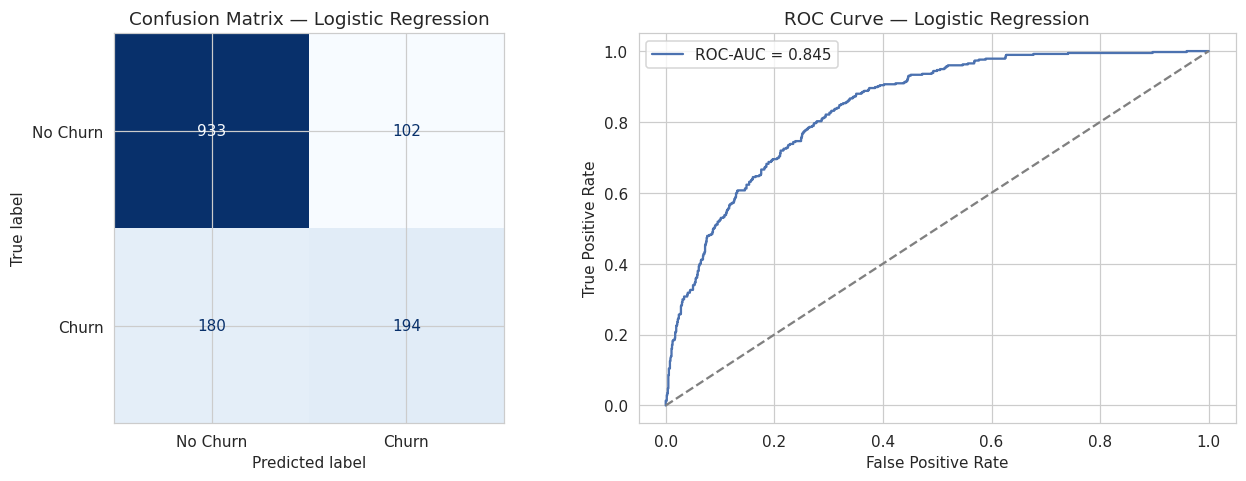

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, final_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title(f"Confusion Matrix — {final_name}")

fpr, tpr, _ = roc_curve(y_test, final_proba)
axes[1].plot(fpr, tpr, color="#4C72B0", label=f"ROC-AUC = {roc_auc_score(y_test, final_proba):.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve — {final_name}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Save the final pipeline

The saved `.pkl` contains the *entire* pipeline — preprocessing and model together — so
scoring new, raw data later is a single `pipeline.predict(new_df)` call with no separate
preprocessing code to keep in sync.


In [15]:
joblib.dump(final_pipeline, "churn_pipeline.pkl")
print(f"Saved final pipeline ({final_name}) to churn_pipeline.pkl")

# Sanity check: reload from disk and confirm identical predictions
reloaded = joblib.load("churn_pipeline.pkl")
reloaded_pred = reloaded.predict(X_test[final_features])
print(f"Reloaded pipeline predictions match original: {(reloaded_pred == final_pred).all()}")

Saved final pipeline (Logistic Regression) to churn_pipeline.pkl
Reloaded pipeline predictions match original: True


## 12. Conclusion

- Wrapping preprocessing in a `ColumnTransformer` + `Pipeline` matched the manual approach's
  score while removing all the manual column-alignment and leakage-prone scaling code.
- Adding `NumServices`, `AvgMonthlyCharge`, and `IsNewCustomer` improved ROC-AUC over the
  base feature set, confirming the engineered features carry real signal about churn risk.
- Because the model is now a single `Pipeline` object, swapping `LogisticRegression` for
  `RandomForestClassifier` — or adding a `GridSearchCV` around the whole thing later —
  requires no changes to the preprocessing code at all.
- The saved `churn_pipeline.pkl` is deployment-ready: feed it raw rows with the same
  columns as `X` and it handles scaling/encoding internally before predicting.
